In [1]:
import os
import torch
import torch.nn as nn
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
class CNN(nn.Module):
    def __init__(self, config):
        super(CNN, self).__init__()
        self.config = config

        self.conv_layers = nn.Sequential(
            nn.Conv2d(9, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.MaxPool2d(2, 2),
        )

        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.fc_layers = nn.Sequential(
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(config['dropout']),
            nn.Linear(32, 1),
        )

    def forward(self, x):
        x = self.conv_layers(x)
        x = self.adaptive_pool(x)
        x = x.view(x.size(0), -1)
        x = self.fc_layers(x)
        x = torch.sigmoid(x)
        return x

In [ ]:
def load_trained_model(model_path, device):
    """Load a trained model from checkpoint."""
    config = {'dropout': 0.3}
    model = CNN(config).to(device)
    
    checkpoint = torch.load(model_path, map_location=device)
    
    if isinstance(checkpoint, dict) and 'model_state_dict' in checkpoint:
        model.load_state_dict(checkpoint['model_state_dict'])
    else:
        model.load_state_dict(checkpoint)
    
    model.eval()  # ← Make sure this is here!
    
    # VERIFY eval mode
    print(f"   Model loaded from {model_path}")
    print(f"   Training mode: {model.training}")  # Should print False
    
    if model.training:
        print("   ⚠️ Forcing eval mode...")
        model.eval()
    
    return model

In [4]:
def load_input_data(gdp_path, pop_path, lc_path):
    """Load and prepare input rasters."""
    
    # Load GDP (normalized)
    with rasterio.open(gdp_path) as src:
        gdp = src.read(1).astype(np.float32)
        profile = src.profile
    
    # Load Population (normalized)
    with rasterio.open(pop_path) as src:
        pop = src.read(1).astype(np.float32)
    
    # Load Land Cover (one-hot encoded)
    with rasterio.open(lc_path) as src:
        lc = src.read().astype(np.float32)
    
    print(f"Loaded data:")
    print(f"  GDP shape: {gdp.shape}")
    print(f"  Pop shape: {pop.shape}")
    print(f"  LC shape: {lc.shape}")
    
    return gdp, pop, lc, profile

In [5]:
def predict_cisi(model, gdp, pop, lc, device, patch_size=32):
    """
    Generate CISI predictions for entire raster.
    
    Returns:
        predictions: numpy array same shape as input rasters
    """
    H, W = gdp.shape
    predictions = np.full((H, W), np.nan, dtype=np.float32)
    
    half_patch = patch_size // 2
    
    # Create valid mask (where all inputs are not NaN)
    valid_mask = ~np.isnan(gdp) & ~np.isnan(pop)
    valid_indices = np.argwhere(valid_mask)
    
    print(f"Predicting for {len(valid_indices):,} valid pixels...")
    
    model.eval()
    with torch.no_grad():
        for idx, (i, j) in enumerate(valid_indices):
            # Extract patch
            i_start = max(0, i - half_patch)
            i_end = min(H, i + half_patch)
            j_start = max(0, j - half_patch)
            j_end = min(W, j + half_patch)
            
            gdp_patch = gdp[i_start:i_end, j_start:j_end].copy()
            pop_patch = pop[i_start:i_end, j_start:j_end].copy()
            lc_patch = lc[:, i_start:i_end, j_start:j_end].copy()
            
            # Handle NaN in patches
            gdp_patch = np.nan_to_num(gdp_patch, nan=0.0)
            pop_patch = np.nan_to_num(pop_patch, nan=0.0)
            
            # Pad if needed
            pad_i = patch_size - gdp_patch.shape[0]
            pad_j = patch_size - gdp_patch.shape[1]
            
            if pad_i > 0 or pad_j > 0:
                gdp_patch = np.pad(gdp_patch, ((0, pad_i), (0, pad_j)))
                pop_patch = np.pad(pop_patch, ((0, pad_i), (0, pad_j)))
                lc_patch = np.pad(lc_patch, ((0, 0), (0, pad_i), (0, pad_j)))
            
            # Stack channels
            input_tensor = np.stack([gdp_patch, pop_patch, *lc_patch], axis=0)
            input_tensor = torch.FloatTensor(input_tensor).unsqueeze(0).to(device)
            
            # Predict
            prediction = model(input_tensor).cpu().item()
            predictions[i, j] = prediction
            
            # Progress
            if (idx + 1) % 1000 == 0:
                print(f"  Processed {idx + 1:,} / {len(valid_indices):,} pixels")
    
    print(f"✅ Prediction complete!")
    print(f"  Valid predictions: {(~np.isnan(predictions)).sum():,}")
    print(f"  Range: [{np.nanmin(predictions):.4f}, {np.nanmax(predictions):.4f}]")
    print(f"  Mean: {np.nanmean(predictions):.4f}")
    
    return predictions

In [6]:
def save_predictions(predictions, output_path, template_profile):
    """Save predictions as GeoTIFF."""
    profile = template_profile.copy()
    profile.update(
        dtype=rasterio.float32,
        count=1,
        nodata=np.nan
    )
    
    with rasterio.open(output_path, 'w', **profile) as dst:
        dst.write(predictions, 1)
    
    print(f"✅ Predictions saved to: {output_path}")

In [7]:
def visualize_predictions(predictions, actual=None):
    """Plot prediction map."""
    fig, axes = plt.subplots(1, 2 if actual is not None else 1, 
                            figsize=(12 if actual is not None else 6, 5))
    
    if actual is not None:
        # Plot actual
        im1 = axes[0].imshow(actual, cmap='RdYlGn', vmin=0, vmax=0.35)
        axes[0].set_title('Actual CISI 2024')
        plt.colorbar(im1, ax=axes[0], label='CISI Score')
        
        # Plot predicted
        im2 = axes[1].imshow(predictions, cmap='RdYlGn', vmin=0, vmax=0.35)
        axes[1].set_title('Predicted CISI 2024')
        plt.colorbar(im2, ax=axes[1], label='CISI Score')
    else:
        # Just plot predictions
        axes = [axes] if not isinstance(axes, np.ndarray) else axes
        im = axes[0].imshow(predictions, cmap='RdYlGn', vmin=0, vmax=0.35)
        axes[0].set_title('Predicted CISI')
        plt.colorbar(im, ax=axes[0], label='CISI Score')
    
    plt.tight_layout()
    plt.show()

Using device: cpu
✅ Model loaded from cisi_model_2024.pth
   Training mode: False
Loaded data:
  GDP shape: (194, 228)
  Pop shape: (194, 228)
  LC shape: (7, 194, 228)
Predicting for 14,259 valid pixels...
  Processed 1,000 / 14,259 pixels
  Processed 2,000 / 14,259 pixels
  Processed 3,000 / 14,259 pixels
  Processed 4,000 / 14,259 pixels
  Processed 5,000 / 14,259 pixels
  Processed 6,000 / 14,259 pixels
  Processed 7,000 / 14,259 pixels
  Processed 8,000 / 14,259 pixels
  Processed 9,000 / 14,259 pixels
  Processed 10,000 / 14,259 pixels
  Processed 11,000 / 14,259 pixels
  Processed 12,000 / 14,259 pixels
  Processed 13,000 / 14,259 pixels
  Processed 14,000 / 14,259 pixels
✅ Prediction complete!
  Valid predictions: 14,259
  Range: [0.0041, 0.1783]
  Mean: 0.0255
✅ Predictions saved to: READY_data\predictions\predicted_cisi_2024_025.tif


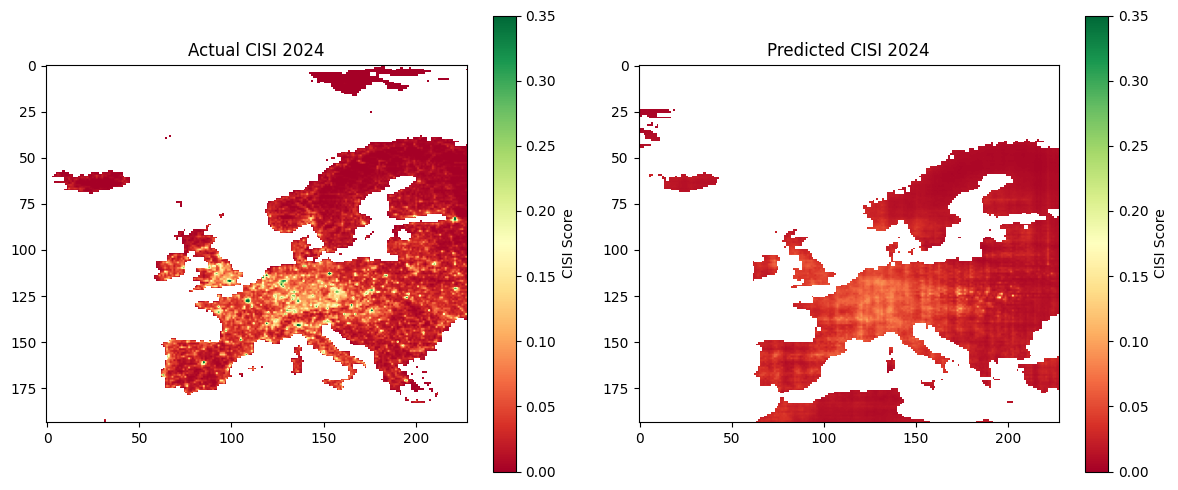


PREDICTION METRICS
R² Score: 0.2372
MAE: 0.0211
RMSE: 0.0369


In [8]:
# ==================================================
# CONFIGURATION
# ==================================================

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths
MODEL_PATH = "cisi_model_2024.pth"  # Your saved model

# Input data (same as training for now - 2024 evaluation)
GDP_PATH = r"READY_data\inputs_normalized\2019_gdp_aligned_025_normalized.tif"
POP_PATH = r"READY_data\inputs_normalized\2020_pop_aligned_025_normalized.tif"
LC_PATH = r"READY_data\landuse_onehot_025\clipped_history_2020_025_onehot.tif"

# Optional: actual CISI for comparison
ACTUAL_CISI_PATH = r"READY_data\labels\2024_CISI_025deg.tif"

# Output
OUTPUT_PATH = r"READY_data\predictions\predicted_cisi_2024_025.tif"

# ==================================================
# RUN PREDICTION
# ==================================================

# 1. Load model
model = load_trained_model(MODEL_PATH, device)

# 2. Load input data
gdp, pop, lc, profile = load_input_data(GDP_PATH, POP_PATH, LC_PATH)

# 3. Generate predictions
predictions = predict_cisi(model, gdp, pop, lc, device, patch_size=32)

# 4. Save predictions
os.makedirs(os.path.dirname(OUTPUT_PATH), exist_ok=True)
save_predictions(predictions, OUTPUT_PATH, profile)

# 5. Visualize (optional - load actual for comparison)
with rasterio.open(ACTUAL_CISI_PATH) as src:
    actual = src.read(1)

visualize_predictions(predictions, actual=actual)

# 6. Calculate metrics (if you have actuals)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

valid_mask = ~np.isnan(predictions) & ~np.isnan(actual)
pred_valid = predictions[valid_mask]
actual_valid = actual[valid_mask]

print("\n" + "="*50)
print("PREDICTION METRICS")
print("="*50)
print(f"R² Score: {r2_score(actual_valid, pred_valid):.4f}")
print(f"MAE: {mean_absolute_error(actual_valid, pred_valid):.4f}")
print(f"RMSE: {np.sqrt(mean_squared_error(actual_valid, pred_valid)):.4f}")

In [10]:
from torch.utils.data import Dataset

class CISIDataset(Dataset):
    def __init__(self, gdp_path, pop_path, lc_path, cisi_path):
        # Load all data
        with rasterio.open(gdp_path) as src:
            self.gdp = src.read(1).astype(np.float32)
        
        with rasterio.open(pop_path) as src:
            self.pop = src.read(1).astype(np.float32)
        
        with rasterio.open(lc_path) as src:
            self.lc = src.read().astype(np.float32)
        
        with rasterio.open(cisi_path) as src:
            self.cisi = src.read(1).astype(np.float32)
        
        # Get valid pixels (where ALL are not NaN)
        valid_gdp = ~np.isnan(self.gdp)
        valid_pop = ~np.isnan(self.pop)
        valid_cisi = ~np.isnan(self.cisi)
        
        self.valid_mask = valid_gdp & valid_pop & valid_cisi
        self.valid_indices = np.argwhere(self.valid_mask)
        
        print(f"Found {len(self.valid_indices)} valid pixels")
    
    def __len__(self):
        return len(self.valid_indices)
    
    def __getitem__(self, idx):
        patch_size = 32
        half_patch = patch_size // 2
        max_tries = 50
        tries = 0

        while True:
            i, j = self.valid_indices[idx]

            # Handle boundaries
            i_start = max(0, i - half_patch)
            i_end = min(self.gdp.shape[0], i + half_patch)
            j_start = max(0, j - half_patch)
            j_end = min(self.gdp.shape[1], j + half_patch)

            # Extract patches
            gdp_patch = self.gdp[i_start:i_end, j_start:j_end].copy()
            pop_patch = self.pop[i_start:i_end, j_start:j_end].copy()
            lc_patch  = self.lc[:, i_start:i_end, j_start:j_end].copy()

            # Pad to patch_size if needed
            pad_i = patch_size - gdp_patch.shape[0]
            pad_j = patch_size - gdp_patch.shape[1]

            if pad_i > 0 or pad_j > 0:
                gdp_patch = np.pad(gdp_patch, ((0, pad_i), (0, pad_j)))
                pop_patch = np.pad(pop_patch, ((0, pad_i), (0, pad_j)))
                lc_patch  = np.pad(lc_patch, ((0, 0), (0, pad_i), (0, pad_j)))

            # Check if patch is valid
            if np.isfinite(gdp_patch).all() and np.isfinite(pop_patch).all():
                break

            # Try different index
            tries += 1
            if tries >= max_tries:
                gdp_patch = np.nan_to_num(gdp_patch, nan=0.0, posinf=0.0, neginf=0.0)
                pop_patch = np.nan_to_num(pop_patch, nan=0.0, posinf=0.0, neginf=0.0)
                break

            idx = np.random.randint(0, len(self.valid_indices))

        # Stack: (9, 32, 32)
        input_tensor = np.stack([gdp_patch, pop_patch, *lc_patch], axis=0)
        target = self.cisi[i, j]

        input_tensor = torch.FloatTensor(input_tensor)
        target = torch.FloatTensor([target])

        return input_tensor, target, (i, j)

TEST 2: R² ON VALIDATION SET
Found 12496 valid pixels

Dataset split:
  Train: 9996 samples
  Val: 2500 samples

Predicting on validation set...

RESULTS

VALIDATION SET METRICS (Current Run):
  R² Score: 0.4587
  MAE: 0.0177
  RMSE: 0.0262

TRAINING METRICS (From Training Run):
  R² Score: 0.4194
  MAE: 0.0181
  RMSE: 0.0263

FULL PREDICTION METRICS (All Pixels):
  R² Score: 0.2372
  MAE: 0.0211
  RMSE: 0.0369

INTERPRETATION
✅ Val R² (0.4587) matches training (0.4194)
   → Model is working correctly!
   → The lower full-data R² (0.24) is REAL
   → Your validation split got 'easier' pixels by chance

📊 CONCLUSION: Model's true performance is ~0.24-0.30
   Consider using spatial splits instead of random splits


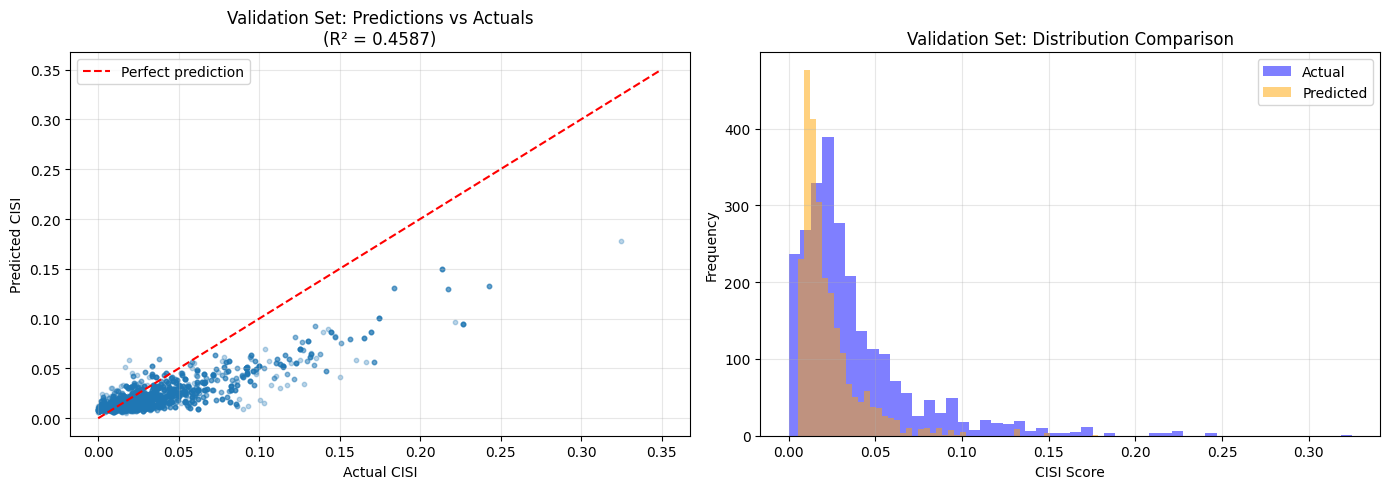

In [12]:
from torch.utils.data import DataLoader
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

print("="*70)
print("TEST 2: R² ON VALIDATION SET")
print("="*70)

# Recreate the EXACT same split from training
# IMPORTANT: If you used a random seed during training, use it here too!

# Create full dataset
dataset = CISIDataset(GDP_PATH, POP_PATH, LC_PATH, ACTUAL_CISI_PATH)

# Split 80/20 (same as training)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

# Use random seed for reproducibility
# If you used a different seed during training, change this!
torch.manual_seed(42)  

train_dataset, val_dataset = torch.utils.data.random_split(
    dataset, 
    [train_size, val_size]
)

print(f"\nDataset split:")
print(f"  Train: {train_size} samples")
print(f"  Val: {val_size} samples")

# Create validation loader
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, drop_last=False)

# Predict on validation set
model.eval()
val_predictions = []
val_actuals = []

print(f"\nPredicting on validation set...")

with torch.no_grad():
    for batch_idx, (inputs, targets, coords) in enumerate(val_loader):
        inputs = inputs.to(device)
        outputs = model(inputs)
        
        val_predictions.extend(outputs.cpu().numpy().flatten())
        val_actuals.extend(targets.numpy().flatten())

val_predictions = np.array(val_predictions)
val_actuals = np.array(val_actuals)

# Calculate metrics
r2_val = r2_score(val_actuals, val_predictions)
mae_val = mean_absolute_error(val_actuals, val_predictions)
rmse_val = np.sqrt(mean_squared_error(val_actuals, val_predictions))

print("\n" + "="*70)
print("RESULTS")
print("="*70)

print("\nVALIDATION SET METRICS (Current Run):")
print(f"  R² Score: {r2_val:.4f}")
print(f"  MAE: {mae_val:.4f}")
print(f"  RMSE: {rmse_val:.4f}")

print("\nTRAINING METRICS (From Training Run):")
print(f"  R² Score: 0.4194")
print(f"  MAE: 0.0181")
print(f"  RMSE: 0.0263")

print("\nFULL PREDICTION METRICS (All Pixels):")
print(f"  R² Score: 0.2372")
print(f"  MAE: 0.0211")
print(f"  RMSE: 0.0369")

print("\n" + "="*70)
print("INTERPRETATION")
print("="*70)

r2_diff = abs(0.4194 - r2_val)

if r2_diff < 0.05:
    print(f"✅ Val R² ({r2_val:.4f}) matches training (0.4194)")
    print("   → Model is working correctly!")
    print("   → The lower full-data R² (0.24) is REAL")
    print("   → Your validation split got 'easier' pixels by chance")
    print("\n📊 CONCLUSION: Model's true performance is ~0.24-0.30")
    print("   Consider using spatial splits instead of random splits")
else:
    print(f"⚠️ Val R² ({r2_val:.4f}) differs from training (0.4194)")
    print(f"   Difference: {r2_diff:.4f}")
    
    if r2_val < 0.30:
        print("   → Model performance degraded!")
        print("   → Something is wrong with model loading or data")
    else:
        print("   → Random split produced different results")
        print("   → Try running training again with fixed seed")

# Visualize comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot
axes[0].scatter(val_actuals, val_predictions, alpha=0.3, s=10)
axes[0].plot([0, 0.35], [0, 0.35], 'r--', label='Perfect prediction')
axes[0].set_xlabel('Actual CISI')
axes[0].set_ylabel('Predicted CISI')
axes[0].set_title(f'Validation Set: Predictions vs Actuals\n(R² = {r2_val:.4f})')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Histogram comparison
axes[1].hist(val_actuals, bins=50, alpha=0.5, label='Actual', color='blue')
axes[1].hist(val_predictions, bins=50, alpha=0.5, label='Predicted', color='orange')
axes[1].set_xlabel('CISI Score')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Validation Set: Distribution Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
